In [56]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

# Make NumPy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)


In [57]:
# 1. Data Setup & Preprocessing
# Load the data
dataset = pd.read_csv('Medical_insurance.csv')
dataset.tail()

,age,sex,bmi,children,smoker,region,charges
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229
2771,54,male,31.600,0,no,southwest,9850.43200


In [58]:
# Clean the data
dataset.isna().sum()
dataset = dataset.dropna()

# Convert categorical variables to numeric
dataset['sex'] = dataset['sex'].map({'male': 1, 'female': 0})
dataset['smoker'] = dataset['smoker'].map({'yes': 1, 'no': 0})
dataset = pd.get_dummies(dataset, columns=['region'], prefix='', prefix_sep='')
dataset.tail()

,age,sex,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
2767,47,0,45.320,1,0,8569.86180,False,False,True,False
2768,21,0,34.600,0,0,2020.17700,False,False,False,True
2769,19,1,26.030,1,1,16450.89470,False,True,False,False
2770,23,1,18.715,0,0,21595.38229,False,True,False,False
2771,54,1,31.600,0,0,9850.43200,False,False,False,True


In [59]:
# Split the data into training and test sets
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

,count,mean,std,min,25%,50%,75%,max
age,2218.0,38.957169,14.176141,18.0000,26.00,39.0000,51.000,64.00000
sex,2218.0,0.504509,0.500092,0.0000,0.00,1.0000,1.000,1.00000
bmi,2218.0,30.676249,6.162375,15.9600,26.18,30.4950,34.800,53.13000
children,2218.0,1.099188,1.211912,0.0000,0.00,1.0000,2.000,5.00000
smoker,2218.0,0.201082,0.400900,0.0000,0.00,0.0000,0.000,1.00000
charges,2218.0,13142.381229,12108.941842,1121.8739,4670.64,9288.0267,16232.847,63770.42801


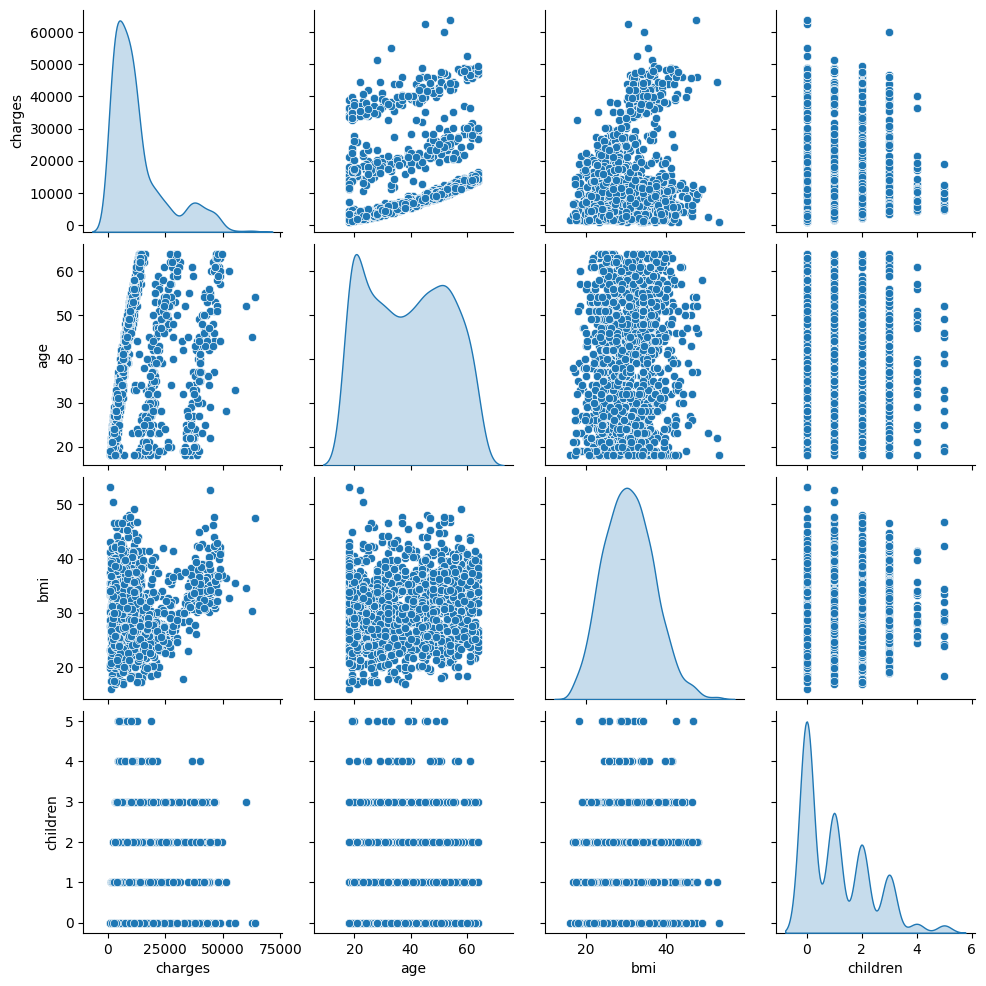

In [60]:
# Inspect the data
sns.pairplot(train_dataset[['charges', 'age', 'bmi', 'children']], diag_kind='kde')
train_dataset.describe().transpose()

In [61]:
# Split features from labels
train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop('charges')
test_labels = test_features.pop('charges')


In [62]:
# 2. Feature Normalization
# Check feature ranges for normalization
train_dataset.describe().transpose()[['mean', 'std']]

# Create normalization layer
normalizer = layers.Normalization(axis=-1)
normalizer.adapt(np.array(train_features))
print(normalizer.mean.numpy())

[[38.957  0.505 30.676  1.099  0.201  0.239  0.239  0.283  0.24 ]]


In [63]:
# 3a. Linear regression with one input ("age")
age = np.array(train_features['age'])

# Create normalization layer
age_normalizer = layers.Normalization(input_shape=[1,], axis=None)
age_normalizer.adapt(age)

# Build the Keras Sequential model
age_model = tf.keras.Sequential([
    age_normalizer,
    layers.Dense(units=1)
])

# Configure the training procedure
age_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error')

# Train the model
history = age_model.fit(
    train_features['age'],
    train_labels,
    epochs=100,
    verbose=0,
    validation_split = 0.2)

/opt/miniconda3/envs/cos30082/lib/python3.11/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


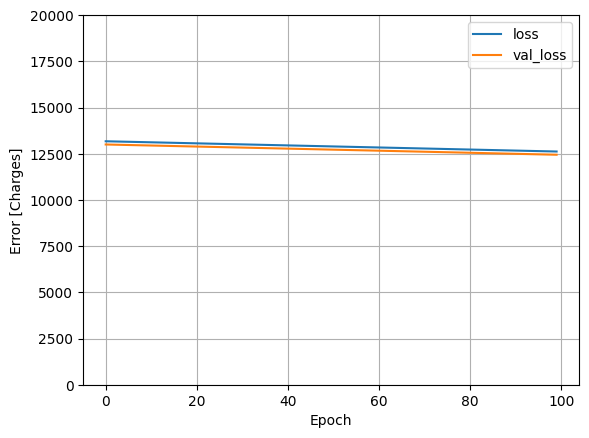

In [64]:
# Visualize the model's training progress
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.ylim([0, 20000])
  plt.xlabel('Epoch')
  plt.ylabel('Error [Charges]')
  plt.legend()
  plt.grid(True)

plot_loss(history)

In [65]:
# Collect results on test set for later
test_results = {}

test_results['age_model'] = age_model.evaluate(
    test_features['age'],
    test_labels, verbose=0)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


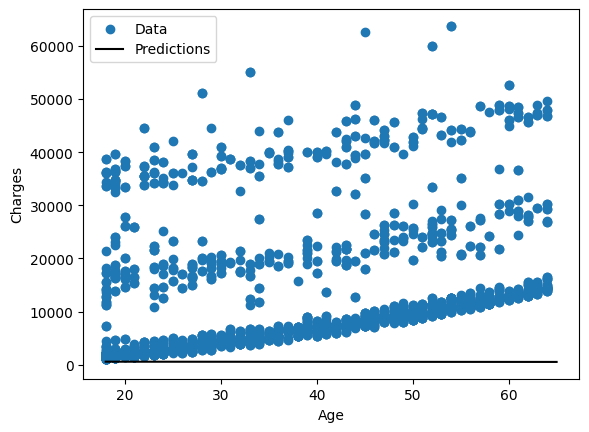

In [66]:
# Visualize predictions vs actual for single variable model
x = tf.linspace(18.0, 65, 100)
y = age_model.predict(x)

def plot_age(x, y):
  plt.scatter(train_features['age'], train_labels, label='Data')
  plt.plot(x, y, color='k', label='Predictions')
  plt.xlabel('Age')
  plt.ylabel('Charges')
  plt.legend()

plot_age(x, y)


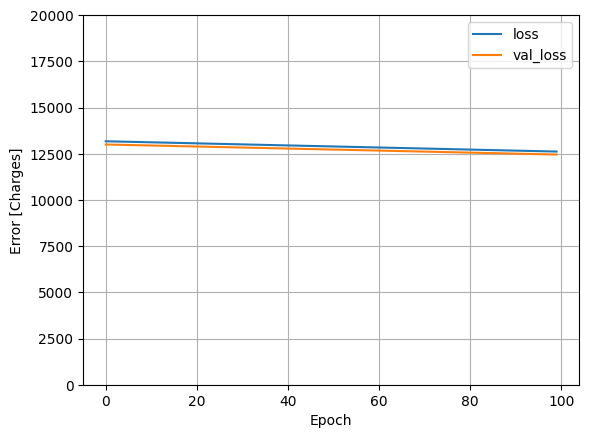

In [67]:
# 3b. Linear regression with multiple inputs
# Build the model
linear_model = tf.keras.Sequential([
    normalizer,
    layers.Dense(units=1)
])

# Configure the model
linear_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error')

# Train the model
history = linear_model.fit(
    train_features,
    train_labels,
    epochs=100,
    verbose=0,
    validation_split = 0.2)

# Plot loss for multiple input model
plot_loss(history)

In [68]:
# Collect the results on the test set for later
test_results['linear_model'] = linear_model.evaluate(
    test_features, test_labels, verbose=0)

In [69]:
# 4. Regression with a DNN
def build_and_compile_model(norm):
  model = keras.Sequential([
      norm,
      layers.Dense(64, activation='relu'),
      layers.Dense(64, activation='relu'),
      layers.Dense(1)
  ])

  model.compile(loss='mean_absolute_error',
                optimizer=tf.keras.optimizers.Adam(0.001))
  return model

In [ ]:
# 4a. DNN with single input (age)
dnn_age_model = build_and_compile_model(age_normalizer)

# Print the model summary
dnn_age_model.summary()

# Train the single input DNN model
history = dnn_age_model.fit(
    train_features['age'],
    train_labels,
    validation_split=0.2,
    verbose=0, epochs=100)

# Plot loss for single input DNN
plot_loss(history)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_8 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,356 (17.02 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 3 (16.00 B)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/stepWARNING:tensorflow:6 out of the last 10 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x15633eca0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


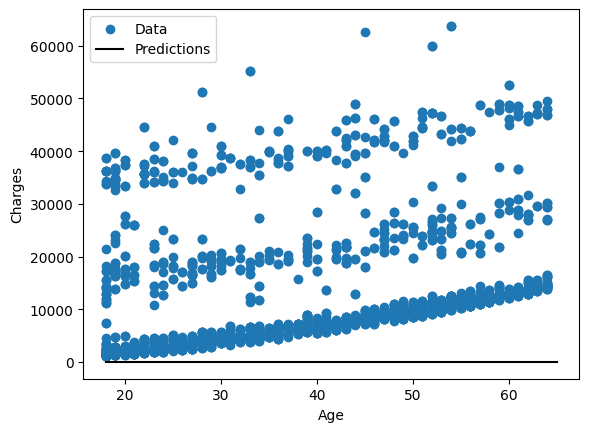

In [ ]:
# Visualize DNN predictions vs actual for single variable
x = tf.linspace(18.0, 65, 100)
y = dnn_age_model.predict(x)

plot_age(x, y)

In [ ]:
# Collect results for single input DNN for later
test_results['dnn_age_model'] = dnn_age_model.evaluate(
    test_features['age'], test_labels,
    verbose=0)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_3 (Normalization) │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

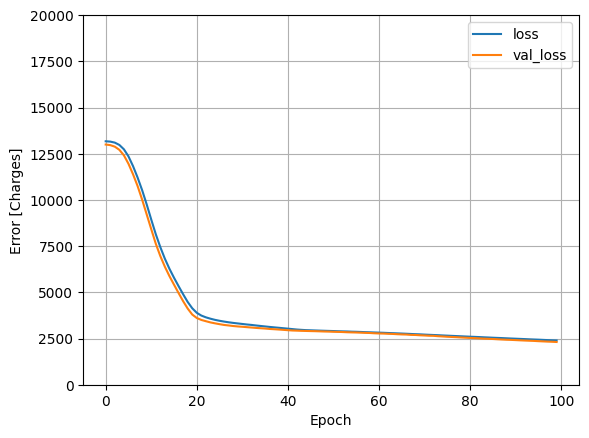

In [ ]:
# 4b.DNN with multiple inputs
dnn_model = build_and_compile_model(normalizer)
dnn_model.summary()

# Train the DNN model
history = dnn_model.fit(
    train_features,
    train_labels,
    validation_split=0.2,
    verbose=0, epochs=100)

# Plot loss for multiple input DNN
plot_loss(history)

In [ ]:
# Collect results for multiple input DNN
test_results['dnn_model'] = dnn_model.evaluate(test_features, test_labels, verbose=0)

In [ ]:
# 6. Performace
pd.DataFrame(test_results, index=['Mean absolute error [Charges]']).T

,Mean absolute error [Charges]
age_model,13178.411133
linear_model,13185.458984
dnn_age_model,7077.808594
dnn_model,2842.466309


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


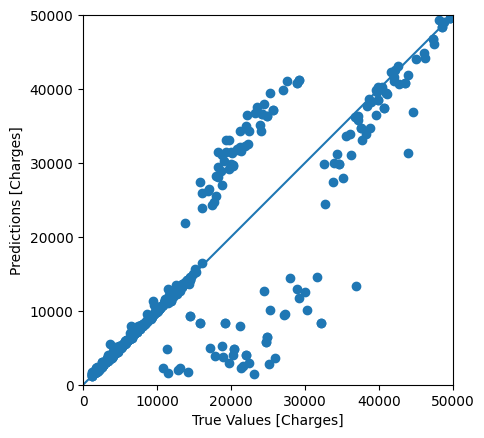

In [ ]:
# Make predictions with the best model (DNN with multiple inputs)
test_predictions = dnn_model.predict(test_features).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True Values [Charges]')
plt.ylabel('Predictions [Charges]')
lims = [0, 50000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)


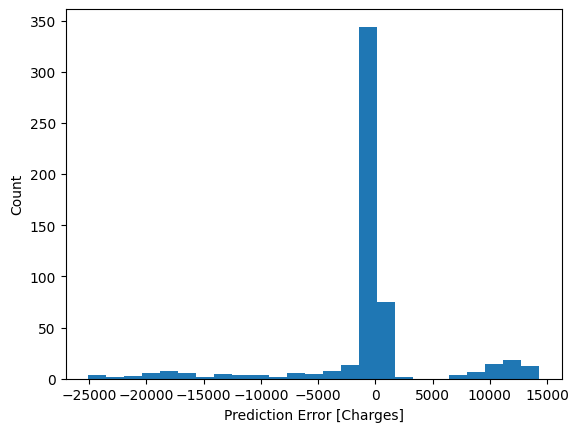

In [ ]:
# Check the error distribution
error = test_predictions - test_labels
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [Charges]')
_ = plt.ylabel('Count')

In [ ]:
# Save the best model
# dnn_model.save('medical_insurance_dnn_model.keras')

# Reload and test the saved model
# reloaded = tf.keras.models.load_model('medical_insurance_dnn_model.keras')

# test_results['reloaded'] = reloaded.evaluate(
#     test_features, test_labels, verbose=0)

# pd.DataFrame(test_results, index=['Mean absolute error [Charges]']).T